<a href="https://colab.research.google.com/github/EdmundoMarquez/AnalisisDatos_IA/blob/main/Hands_On_Introducci%C3%B3n_a_la_Estad%C3%ADstica_Inferencial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HANDS ON: INTRODUCCIÓN A ESTADÍSTICA INFERENCIAL**


Una vez visto la presentación ***Introducción a la estadística inferencial***, se proporciona el siguiente ***colab*** para que **el alumnado pueda practicar** haciendo uso del lenguaje de programación ***python***.


## **PRUEBA DE HIPÓTESIS**

La **prueba de hipótesis** es un procedimiento formal dentro de la estadística inferencial que se usa para aceptar o rechazar una afirmación sobre un parámetro poblacional. Se basa en comparar dos hipótesis opuestas: la nula ($H_0$) y la alternativa ($H_1$).

***NOTA:*** *Se hará el uso de las bibliotecas de **Pandas**, **Seaborn** y **Scipy** para usar datasets precargados y operaciones estadísticas sin entrar a tanto detalle a las librerías mismas. Para ello, se explicará mas a detalle en el siguiente módulo.*

In [2]:
# Importar librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# Importar dataset
df_tips = sns.load_dataset('tips')
print(df_tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


### **NIVEL DE SIGNIFICANCIA:**

Es el umbral de error que estamos dispuestos a aceptar. Comúnmente se utiliza **$\alpha = 0.01, 0.05, 0.1$** representando el 1%, 5%, y 10% de nivel de significancia correspondientemente.

* Si el **p-value < $\alpha$**: Rechazamos $H_0$ (Hay evidencia estadística).

* Si el **p-value > $\alpha$**: No podemos rechazar $H_0$ (No hay suficiente evidencia).

In [4]:
# Importar módulo
from scipy import stats


**Caso práctico:** ¿Existe una diferencia significativa entre la propina que dan los fumadores vs. los no fumadores?

* $H_0$: La media de propinas es igual para ambos grupos.

* $H_1$: La media de propinas es distinta entre fumadores y no fumadores.

In [5]:
# Separaración de grupos
propinas_fumadores = df_tips[df_tips["smoker"] == "Yes"]["tip"]
propinas_no_fumadores = df_tips[df_tips["smoker"] == "No"]["tip"]

In [6]:
# Aplicar Prueba T de Student
t_stat, p_value = stats.ttest_ind(propinas_fumadores, propinas_no_fumadores)
print(f"Estadistico T: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

Estadistico T: 0.0922
p-value: 0.9266


In [7]:
# Interpretar resultados
if p_value < 0.01:
  print("Conclusión: Rechazamos la hipótesis nula (H0)")
  print("Existe una diferencia muy significativa entre la propina de ambos grupos.")
elif p_value >= 0.01 and p_value < 0.05:
  print("Conclusión: Rechazamos la hipótesis nula (H0)")
  print("Existe una diferencia altamente significativa entre la propina de ambos grupos.")
elif p_value >= 0.05 and p_value < 0.1:
  print("Conclusión: No podemos rechazar la hipotesis nula (H0)")
  print("No existe una diferencia altamente significativa entre la propina de ambos grupos.")
else:
  print("Conclusión: No podemos rechazar la hipotesis nula (H0)")
  print("No hay evidencia suficiente para decir que las propinas son diferentes.")

Conclusión: No podemos rechazar la hipotesis nula (H0)
No hay evidencia suficiente para decir que las propinas son diferentes.


## **APRENDIZAJE ESTADÍSTICO**

El **aprendizaje estadístico** es un marco de trabajo que **combina la estadística y la computación** para construir **modelos predictivos o de clasificación** a partir de los datos. Es la base teórica de lo que hoy conocemos como Machine Learning.

### **REGRESIÓN LINEAL SIMPLE:**



Una **regresión lineal simple** es un método estadístico utilizado para modelar la relación entre una variable independiente, el cual actua como una **variable predictora**, y una variable dependiente que actua como una **variable objetivo**.

Su objetivo es encontrar una línea recta que mejor se ajuste a los datos para **predecir un valor objetivo en función del valor predictor**.

Una regresión lineal tiene la forma:

\begin{equation} \overline{y} = β\overline{x} + α  \, \, \, \equiv \, \, \, y = mx + b \end{equation}

Y su función de costo:

\begin{equation} c(x) = \frac{1}{n} Σ_{i=1}^n(\overline{y} - y_i)² \end{equation}

In [8]:
# Definir regresión lineal
x = df_tips["total_bill"]
y = df_tips["tip"]
linear_regression = np.polyfit(x, y, deg=1)
beta, alpha = linear_regression
print(f"y={beta}, x + {alpha}")

y=0.10502451738435338, x + 0.920269613554673


In [9]:
# Predicción de valores con regresión lineal
value_user = int(input("Agrega el total de la cuenta que deseas predecir: "))
y_pred = round(beta*value_user+alpha, 2)
print(f"El valor predicho de la propina es de ${y_pred}")

Agrega el total de la cuenta que deseas predecir: 17
El valor predicho de la propina es de $2.71


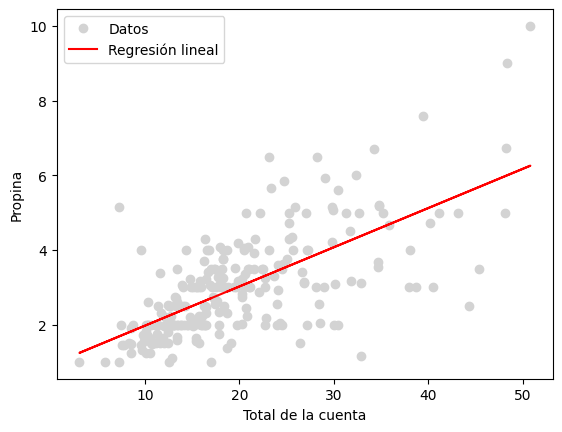

In [10]:
# Visualizar regresión lineal
plt.plot(x, y, 'o', color = "lightgray", label = "Datos")
plt.plot(x, beta*x+alpha, color = "red", label = "Regresión lineal")
plt.xlabel("Total de la cuenta")
plt.ylabel("Propina")
plt.legend()
plt.show()

In [11]:
# Iterar pérdida de la regresión lineal
num_iteraciones = 100
perdida = []
for i in range(num_iteraciones):
  y_pred = np.polyval(linear_regression, x)
  error = ((y - y_pred)**2).mean()
  perdida.append(error)
print(perdida)

[np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.float64(1.036019442011377), np.floa

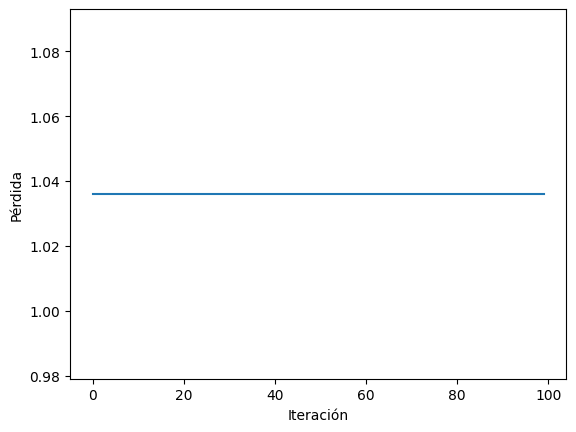

In [12]:
# Visualizar pérdida de la regresión lineal
plt.plot(perdida)
plt.xlabel("Iteración")
plt.ylabel("Pérdida")
plt.show()


### **DESCENSO DE GRADIENTE:**

El **descenso de gradiente** es un algoritmo de optimización ampliamente utilizado en el campo del aprendizaje automático y en la resolución numérica de problemas de optimización.

Su objetivo principal es encontrar el **mínimo de una función**, lo que es esencial en la optimización de modelos y la resolución de problemas matemáticos, para ajustar los parámetros de manera que la **función de costo se minimice**.

El descenso de gradiente tiene la forma:

\begin{equation} (ϴ_0, ϴ_1)_{i+1} = (ϴ_0, ϴ_1)_i - α * \frac{∂\,\,c(ϴ_0, ϴ_1)}{∂(ϴ_0, ϴ_1)} \, \, \,\, \, \,\, \, \, ; \, \, \,\, \, \,\, \, \, α \in (0, 1) \end{equation}

Donde su predicción:

\begin{equation} h_ϴ(x) = ϴ_1x + ϴ_0  \, \, \, \equiv \, \, \, y = mx + b \end{equation}


In [13]:
# Definir parámetros
tamaño_paso = 0.0001
theta_0 = 0
theta_1 = 0

perdida = []

La función de costo tiene la forma:

\begin{equation} c(ϴ_0, ϴ_1) = \frac{1}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i)² \end{equation}

Al derivar función de costo:

*   Parámetro 1:

\begin{equation} \frac{∂}{∂(ϴ_0)}\ c(ϴ_0, ϴ_1) =  \frac{2}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i) \end{equation}


*   Paramétro 2:

\begin{equation} \frac{∂}{∂(ϴ_1)}\ c(ϴ_0, ϴ_1) =  \frac{2}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i)(x_i) \end{equation}

In [14]:
# Realizar algoritmo del descenso de gradiente
num_iteraciones = 100

for i in range(num_iteraciones):
  y_pred = theta_1 * x + theta_0
  error = ((y- y_pred)**2).mean()
  perdida.append(error)

  d_theta_0 = (2 / len(x)) * np.sum(y_pred - y)
  d_theta_1 = (2 / len(x)) * np.sum((y_pred - y) * x)

  theta_0 = theta_0 - tamaño_paso * d_theta_0
  theta_1 = theta_1 - tamaño_paso * d_theta_1

print(f"y = {theta_1} x + {theta_0}")

y = 0.14335579777765065 x + 0.009094636407633543


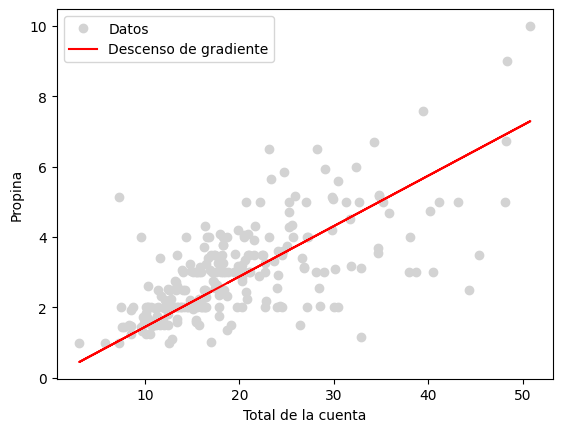

In [15]:
# Visualizar la regresión lineal por descenso de gradiente
plt.plot(x, y, 'o', color = "lightgray", label = "Datos")
plt.plot(x, theta_1*x+theta_0, color="red", label = "Descenso de gradiente")
plt.xlabel("Total de la cuenta")
plt.ylabel("Propina")
plt.legend()
plt.show()

In [16]:
# Predicción de valores con descenso de gradiente
value_user = int(input("Agrega el total de la cuenta que deseas predecir: "))
y_pred = round(theta_1 * value_user + theta_0, 2)
print(f"La propina será de ${y_pred}")

Agrega el total de la cuenta que deseas predecir: 17
La propina será de $2.45


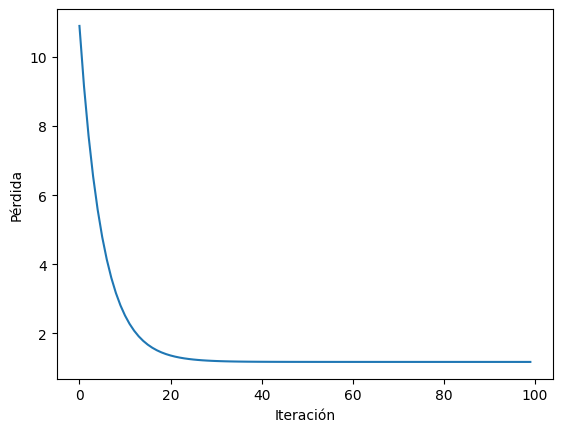

In [17]:
# Visualizar las pérdidas
plt.plot(perdida)
plt.xlabel("Iteración")
plt.ylabel("Pérdida")
plt.show()

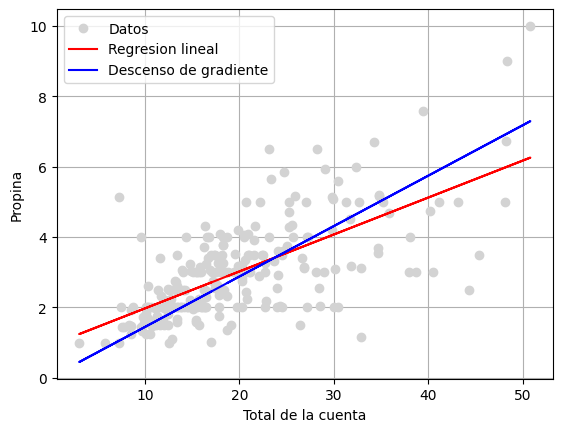

In [18]:
# Comparar las rectas obtenidas por los algoritmos
plt.plot(x, y, "o", color = "lightgray", label="Datos")
plt.plot(x, beta * x + alpha, color = "red", label = "Regresion lineal")
plt.plot(x, theta_1 * x + theta_0, color = "blue", label = "Descenso de gradiente")
plt.xlabel("Total de la cuenta")
plt.ylabel("Propina")
plt.legend()
plt.grid()
plt.show()

## **CHALLENGE: ANÁLISIS PREDICTIVO DE DATOS**

Una vez visto el ***Hands - On: Introducción a la estadística inferencial***, se presentan las siguientes actividades para que el alumnado pueda repasar y reforzar lo aprendido dentro de la clase.

Dentro de la siguiente dinámica, **se realizará un análisis de estadística inferecial** haciendo uso de **operaciones vectorizadas y visualización de datos** a través del **dataset taxis** proveniente de la librería de ***Seaborn***.

Donde los análisis a realizar son:

*   **Prueba de hipótesis**
*   **Aprendizaje estadístico**

**IMPORTANTE:** Para su revisión, **es indispensable que los apartados anteriores se encuentren llenados con el código visto durante la sesión.**

### **INSTRUCCIONES:**

**1. Importa las librerías:** Carga las bibliotecas de Numpy, Pandas, Seaborn y Matplotlib.pyplot.










In [19]:
# Importar librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


**2. Importa el dataset de taxis:** Crea una variable denominada df_taxis donde se importe el dataset taxis.

In [20]:
# Importar dataset
df_taxis = sns.load_dataset('taxis')
print(df_taxis)

df_taxis.describe()

                  pickup             dropoff  passengers  distance  fare  \
0    2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0   
1    2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0   
2    2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5   
3    2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0   
4    2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0   
...                  ...                 ...         ...       ...   ...   
6428 2019-03-31 09:51:53 2019-03-31 09:55:27           1      0.75   4.5   
6429 2019-03-31 17:38:00 2019-03-31 18:34:23           1     18.74  58.0   
6430 2019-03-23 22:55:18 2019-03-23 23:14:25           1      4.14  16.0   
6431 2019-03-04 10:09:25 2019-03-04 10:14:29           1      1.12   6.0   
6432 2019-03-13 19:31:22 2019-03-13 19:48:02           1      3.85  15.0   

       tip  tolls  total   color      payment            pickup_zone  \
0     2.15    0

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


**3. Realiza una prueba de hipótesis:** Determina si existe una diferencia significativa entre la distancia recorrida de los taxis color amarillo y verde.

Donde:

   * H0: La media de distancia es igual para ambos colores.
   * H1: La media de distancia es distinta entre colores.

In [21]:
# Importar módulo
from scipy import stats

In [22]:
# Separación de grupos
taxis_amarillos = df_taxis[df_taxis["color"] == "yellow"]["distance"]
taxis_verdes = df_taxis[df_taxis["color"] == "green"]["distance"]

In [23]:
# Aplicar Prueba T de Student
t_stat, p_value = stats.ttest_ind(taxis_amarillos, taxis_verdes)
print(f"Estadistico T: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

Estadistico T: -3.4060
p-value: 0.0007


In [24]:
# Interpretación automática
if p_value < 0.01:
  print("Conclusión: Rechazamos la hipótesis nula (H0)")
  print("Existe una diferencia muy significativa entre la propina de ambos grupos.")
elif p_value >= 0.01 and p_value < 0.05:
  print("Conclusión: Rechazamos la hipótesis nula (H0)")
  print("Existe una diferencia altamente significativa entre la propina de ambos grupos.")
elif p_value >= 0.05 and p_value < 0.1:
  print("Conclusión: No podemos rechazar la hipotesis nula (H0)")
  print("No existe una diferencia altamente significativa entre la propina de ambos grupos.")
else:
  print("Conclusión: No podemos rechazar la hipotesis nula (H0)")
  print("No hay evidencia suficiente para decir que las propinas son diferentes.")

Conclusión: Rechazamos la hipótesis nula (H0)
Existe una diferencia muy significativa entre la propina de ambos grupos.


**4. Realiza un aprendizaje estadístico:**

   * Crea un modelo de regresión lineal simple para predecir el costo del viaje en función de la distancia recorrida.
   * Ajusta el modelo a través del algoritmo de optimización del descenso de gradiente.
   * Utiliza el modelo ajustado para realizar una predicción de cuánto costará un viaje de dado un valor agregado por el usuario en unidades de distancia.

In [25]:
# Definir regresión lineal
x = df_taxis["distance"]
y = df_taxis["total"]
linear_regression = np.polyfit(x, y, deg=1)
beta, alpha = linear_regression
print(f"y={beta}, x + {alpha}")

y=3.2651658040714597, x + 8.641918776697052


In [26]:
# Realizar algoritmo del descenso de gradiente
tamaño_paso = 0.0001
theta_0 = 0
theta_1 = 0

perdida = []

num_iteraciones = 100

for i in range(num_iteraciones):
  y_pred = theta_1 * x + theta_0
  error = ((y- y_pred)**2).mean()
  perdida.append(error)

  d_theta_0 = (2 / len(x)) * np.sum(y_pred - y)
  d_theta_1 = (2 / len(x)) * np.sum((y_pred - y) * x)

  theta_0 = theta_0 - tamaño_paso * d_theta_0
  theta_1 = theta_1 - tamaño_paso * d_theta_1

print(f"y = {theta_1} x + {theta_0}")

y = 1.6471042716040312 x + 0.3137121806752133


In [27]:
# Predicción de valores con descenso de gradiente
value_user = int(input("Agrega la distancia que vas a recorrer (km): "))
y_pred = round(theta_1 * value_user + theta_0, 2)
print(f"La cuenta será de ${y_pred}")

Agrega la distancia que vas a recorrer (km): 20
La cuenta será de $33.26


**5. Visualiza los resultados:**

   * Grafica las líneas de las regresiones para comparar entre la regresión lineal simple y el algoritmo de optimización.
   * Grafica la función de costo resultante del ajuste con el algoritmo de optimización.

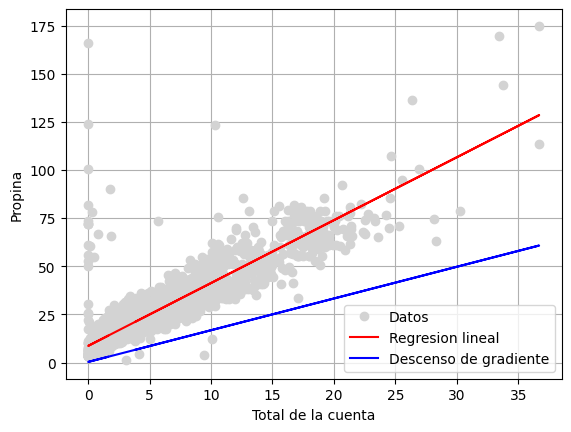

In [28]:
# Comparar las rectas obtenidas por los algoritmos
plt.plot(x, y, "o", color = "lightgray", label="Datos")
plt.plot(x, beta * x + alpha, color = "red", label = "Regresion lineal")
plt.plot(x, theta_1 * x + theta_0, color = "blue", label = "Descenso de gradiente")
plt.xlabel("Total de la cuenta")
plt.ylabel("Propina")
plt.legend()
plt.grid()
plt.show()

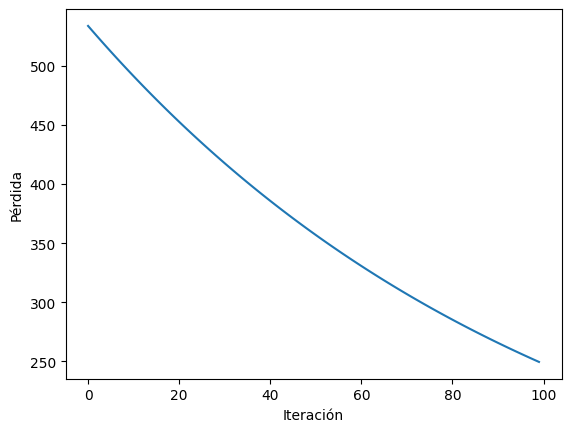

In [29]:
# Visualizar función de costo
plt.plot(perdida)
plt.xlabel("Iteración")
plt.ylabel("Pérdida")
plt.show()